# BioDYM Material Flow Analysis - Scientific Notebook

A streamlined notebook for Material Flow Analysis using the BioDYM framework with enhanced plotting capabilities. 

## Workflow Overview

This notebook follows a structured approach to Material Flow Analysis:

1. **Setup and Data Loading** - Prepare environment and load input data
2. **Calculation & Validation** - Execute MFA analysis and verify results
3. **Visualization** - Comprehensive analysis and exploration
4. **Scenario & Uncertainty Manager** - (Optional) Compare scenarios and run Monte Carlo analysis
5. **Data Export** - Save results and generate documentation

---

# 1. Setup and Data Loading

This section prepares the analysis environment and loads the input data.

## 1.1 Environment Setup

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from IPython.display import display, HTML, Markdown
import copy

In [ ]:
# Add BioDYM modules to path
src_path = os.path.join(os.getcwd(), 'src')
sys.path.insert(0, src_path)

In [ ]:
# Add ODYM framework to path
biodym_mfa_tool_dir = os.getcwd()
odym_path = os.path.join(
    biodym_mfa_tool_dir, "framework", "ODYM-master_20241127", "odym", "modules"
)
sys.path.insert(0, odym_path)

In [ ]:
# Add bioDYM add-on to path
biodym_addon_path = os.path.join(
    biodym_mfa_tool_dir, "framework", "bioDYM_add-on", "modules"
)
sys.path.insert(0, biodym_addon_path)

In [ ]:
# Import BioDYM modules
try:
    import config
    import data_loader
    import system_setup
    import utils
    from engine import solver
    from src import plotting
    import ODYM_Classes as msc
    print("✅ BioDYM modules imported successfully")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("   Current Python path:")
    for i, path in enumerate(sys.path[:5]):  # Show first 5 paths
        print(f"   {i}: {path}")
    raise

✅ BioDYM modules imported successfully


In [ ]:
# Set up plotting
plt.style.use('default')
print("📊 Plotting environment ready")

📊 Plotting environment ready


## 1.2 Data Input Configuration

In [ ]:
# This is the only manual path setting required.
input_file = "data/01_input/250916_CS1_Wheat_Straw.xlsx"
print(f"📁 Input file: {input_file}")
if not os.path.exists(input_file):
    raise FileNotFoundError(f"Input file not found: {input_file}")

📁 Input file: data/01_input/250916_CS1_Wheat_Straw.xlsx


## 1.3 System Configuration Extraction

In [ ]:
print("\n" + "="*60)
print("⚙️ EXTRACTING CONFIGURATION FROM EXCEL")
print("="*60)


⚙️ EXTRACTING CONFIGURATION FROM EXCEL


In [ ]:
# Load the full dataset once. This will be passed to functions that need it.
input_data = pd.read_excel(
    input_file, sheet_name=None, header=0, engine='openpyxl', na_values=['N.A.', 'NA', 'n/a']
)
print(f"✅ Excel file loaded: {len(input_data)} sheets")

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


✅ Excel file loaded: 25 sheets


c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  

In [ ]:
# Use the robust loader from the config module. This function handles all errors
# and fallbacks, guaranteeing a valid config object is returned.
config_obj = config.load_configuration(input_file)
print("✅ Configuration object loaded.")

✅ Found configuration sheet: '0_Configuration'
✅ Configuration object loaded.


In [ ]:
# Extract core values from the config object, with fallbacks to data-driven values
try:
    start_year = int(config_obj.Start_Year)
    end_year = int(config_obj.End_Year)
    elements = [elem.strip() for elem in config_obj.Elements.split(',')]
except Exception as e:
    print(f"⚠️ Could not get time/elements from config object: {e}. Falling back to data-driven values.")
    flow_data = input_data['1_2_Data_Flows']
    years = sorted(flow_data['Year_Flow'].unique())
    start_year = int(min(years))
    end_year = int(max(years))
    elements = ['material', 'WC', 'DM', 'CC']

In [ ]:
# Display final configuration summary
run_scenario = getattr(config_obj, 'Run_Scenario_Analysis', False)
selected_scenario = getattr(config_obj, 'Selected_Scenario_Name 1', getattr(config_obj, 'Selected_Scenario_Name', 'N/A'))

In [ ]:
print(f"\n-- Configuration Summary --")
print(f"📅 Time range: {start_year} - {end_year}")
print(f"🧪 Elements: {elements}")
print(f"🎲 Monte Carlo: {'Enabled' if config_obj.RUN_MONTE_CARLO else 'Disabled'}")
print(f"📊 DSM Calculation: {'Enabled' if config_obj.RUN_DSM_CALCULATION else 'Disabled'}")
print(f"🌱 FOMP Calculation: {'Enabled' if config_obj.RUN_FOMP_CALCULATION else 'Disabled'}")
print(f"🎭 Scenario Analysis: {'Enabled' if run_scenario else 'Disabled'}")
if run_scenario:
    print(f"   -> Selected Scenario: '{selected_scenario}'")


-- Configuration Summary --
📅 Time range: 2025 - 2050
🧪 Elements: ['material', 'WC', 'DM', 'CC']
🎲 Monte Carlo: Enabled
📊 DSM Calculation: Disabled
🌱 FOMP Calculation: Enabled
🎭 Scenario Analysis: Disabled


# 2. Calculation and Validation

In [ ]:
# ## 2.1 Model Initialization & Calculation
print("\n" + "="*60)
print("🚀 RUNNING BASELINE MFA CALCULATION")
print("="*60)


🚀 RUNNING BASELINE MFA CALCULATION


In [ ]:
print("📋 Setting up model scope...")
model_classification, index_table = system_setup.define_model_scope(start_year, end_year, elements)

📋 Setting up model scope...
--> Model scope and classifications defined.


In [ ]:
print("🔧 Initializing MFA system...")
mfa_system_base = system_setup.initialize_mfa_system(model_classification, index_table)

🔧 Initializing MFA system...
--> MFA system object initialized.


In [ ]:
print("📊 Loading processes and data...")
mfa_system_base, all_excel_data = system_setup.load_and_define_processes(mfa_system_base, input_data, data_loader)

📊 Loading processes and data...
--> Defining process and stock structures...
--> Validating input data structure...
--> Input data validation successful.
--> Stock values initialized.


In [ ]:
print("🔗 Defining flows and base parameters (e.g., compositions from flowsheet)...")
mfa_system_configured, _ = system_setup.define_flows_and_parameters(mfa_system_base, all_excel_data)

🔗 Defining flows and base parameters (e.g., compositions from flowsheet)...
--> Defining flows, parameters, and setting all initial values...
--> All flows initialized to zero.
--> Populated data for primary input flows.


In [ ]:
print("⚙️ Loading all model parameters (TCs, DSM, FOMP)...")

⚙️ Loading all model parameters (TCs, DSM, FOMP)...


In [ ]:
# Centralized call to the new, unified TC loader
time_vector = mfa_system_configured.IndexTable.Classification['Time'].Items
elements_list = mfa_system_configured.Elements
tc_params = data_loader.load_tc_parameters(all_excel_data, elements_list, time_vector)
mfa_system_configured.ParameterDict.update(tc_params) # Add the new TC params to the system

--> Loading Transfer Coefficients (TCs)...
  -> Loading TC: TC_02_03 (from Process 2)... Applying 'Splitter' logic.
  -> Loading TC: TC_03_05 (from Process 3)... Applying 'Splitter' logic.
  -> Loading TC: TC_03_04 (from Process 3)... Applying 'Splitter' logic.
  -> Loading TC: TC_05_06 (from Process 5)... Applying 'Splitter' logic.
  -> Loading TC: TC_05_07 (from Process 5)... Applying 'Splitter' logic.
  -> Loading TC: TC_05_09 (from Process 5)... Applying 'Splitter' logic.
  -> Loading TC: TC_04_00 (from Process 4)... Applying 'Transformer' logic.
  -> Loading TC: TC_04_01 (from Process 4)... Applying 'Transformer' logic.
  -> Loading TC: TC_07_00 (from Process 7)... Applying 'Transformer' logic.
  -> Loading TC: TC_07_01 (from Process 7)... Applying 'Transformer' logic.
  -> Loading TC: TC_06_08 (from Process 6)... Applying 'Splitter' logic.
  -> Loading TC: TC_08_00 (from Process 8)... Applying 'nan' logic.
  -> Loading TC: TC_08_01 (from Process 8)... Applying 'nan' logic.
  -> L

In [ ]:
# Load other special model parameters
dsm_params = data_loader.load_dsm_parameters(all_excel_data)
if config_obj.RUN_FOMP_CALCULATION:
    fomp_params = data_loader.load_fomp_parameters(all_excel_data)
else:
    fomp_params = {}
uncertainty_params = data_loader.load_uncertainty_definitions(all_excel_data)

--> Loading DSM parameters from sheet '3_1_Definition_DSM'...
--> Successfully loaded configurations for 0 DSM process(es).
--> Loading FOMP parameters from sheet '3_2_Definition_FOMP'...
--> Successfully loaded configurations for 2 FOMP process(es).
--> Loading uncertainty definitions from sheet '4_1_Uncertainty_Parameters'...
--> Successfully loaded 0 uncertainty parameter definition(s).


In [ ]:
print("✅ All parameters loaded and configured.")

✅ All parameters loaded and configured.


In [ ]:
print("🧮 Running baseline calculation...")
mfa_results_baseline, dsm_details_baseline = solver.run_mfa_calculation(mfa_system_configured, dsm_params, fomp_params, config_obj)
print("✅ Baseline calculation completed successfully!")

🧮 Running baseline calculation...
   Total carbon output: 2072601.70
   Total environmental output: 2245318.50
   Total carbon output: 94952.56
   Total environmental output: 87648.52
   Total carbon output: 2072601.70
   Total environmental output: 2245318.50
   Total carbon output: 94952.56
   Total environmental output: 87648.52
   Total carbon output: 2072601.70
   Total environmental output: 2245318.50
   Total carbon output: 94952.56
   Total environmental output: 87648.52
   Total carbon output: 2072601.70
   Total environmental output: 2245318.50
   Total carbon output: 94952.56
   Total environmental output: 87648.52
   Total carbon output: 2072601.70
   Total environmental output: 2245318.50
   Total carbon output: 94952.56
   Total environmental output: 87648.52
   Total carbon output: 2072601.70
   Total environmental output: 2245318.50
   Total carbon output: 94952.56
   Total environmental output: 87648.52
   Total carbon output: 2072601.70
   Total environmental output: 

## 2.2 Mass Balance Validation

In [ ]:
print("\n" + "="*60)
print("⚖️ MASS BALANCE VERIFICATION (BASELINE)")
print("="*60)
plotting.plot_total_mass_balance_error(mfa_results_baseline)
plotting.plot_optimized_mass_balance_error(mfa_results_baseline)


⚖️ MASS BALANCE VERIFICATION (BASELINE)


interactive(children=(IntSlider(value=2025, description='Year', max=2050, min=2025), Dropdown(description='Ele…

FigureWidget({
    'data': [{'marker': {'color': [#7f7f7f, #7f7f7f, #7f7f7f, #7f7f7f, #7f7f7f,
                                   #7f7f7f, #7f7f7f, #7f7f7f, #7f7f7f, #7f7f7f,
                                   #7f7f7f, #7f7f7f]},
              'type': 'bar',
              'uid': 'aa621364-197b-4180-8dd1-52f5652f357e',
              'x': [Atmosphere, Environment, Cultivation, Harvest, Grain
                    Processing & Consumption, Straw C&D, Direct Incorporation,
                    Animal bedding, Lithosphere (DI), Compostation & Incorporation,
                    Lithosphere (C&I), Water Compostation],
              'y': [0.0, 0.0, 1.1641532182693481e-10, -1.1641532182693481e-10,
                    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}],
    'layout': {'height': 500,
               'shapes': [{'line': {'color': 'black', 'width': 2},
                           'type': 'line',
                           'x0': -0.5,
                           'x1': 11.5,
                        


--- System Flow Diagram (Graphviz) ---


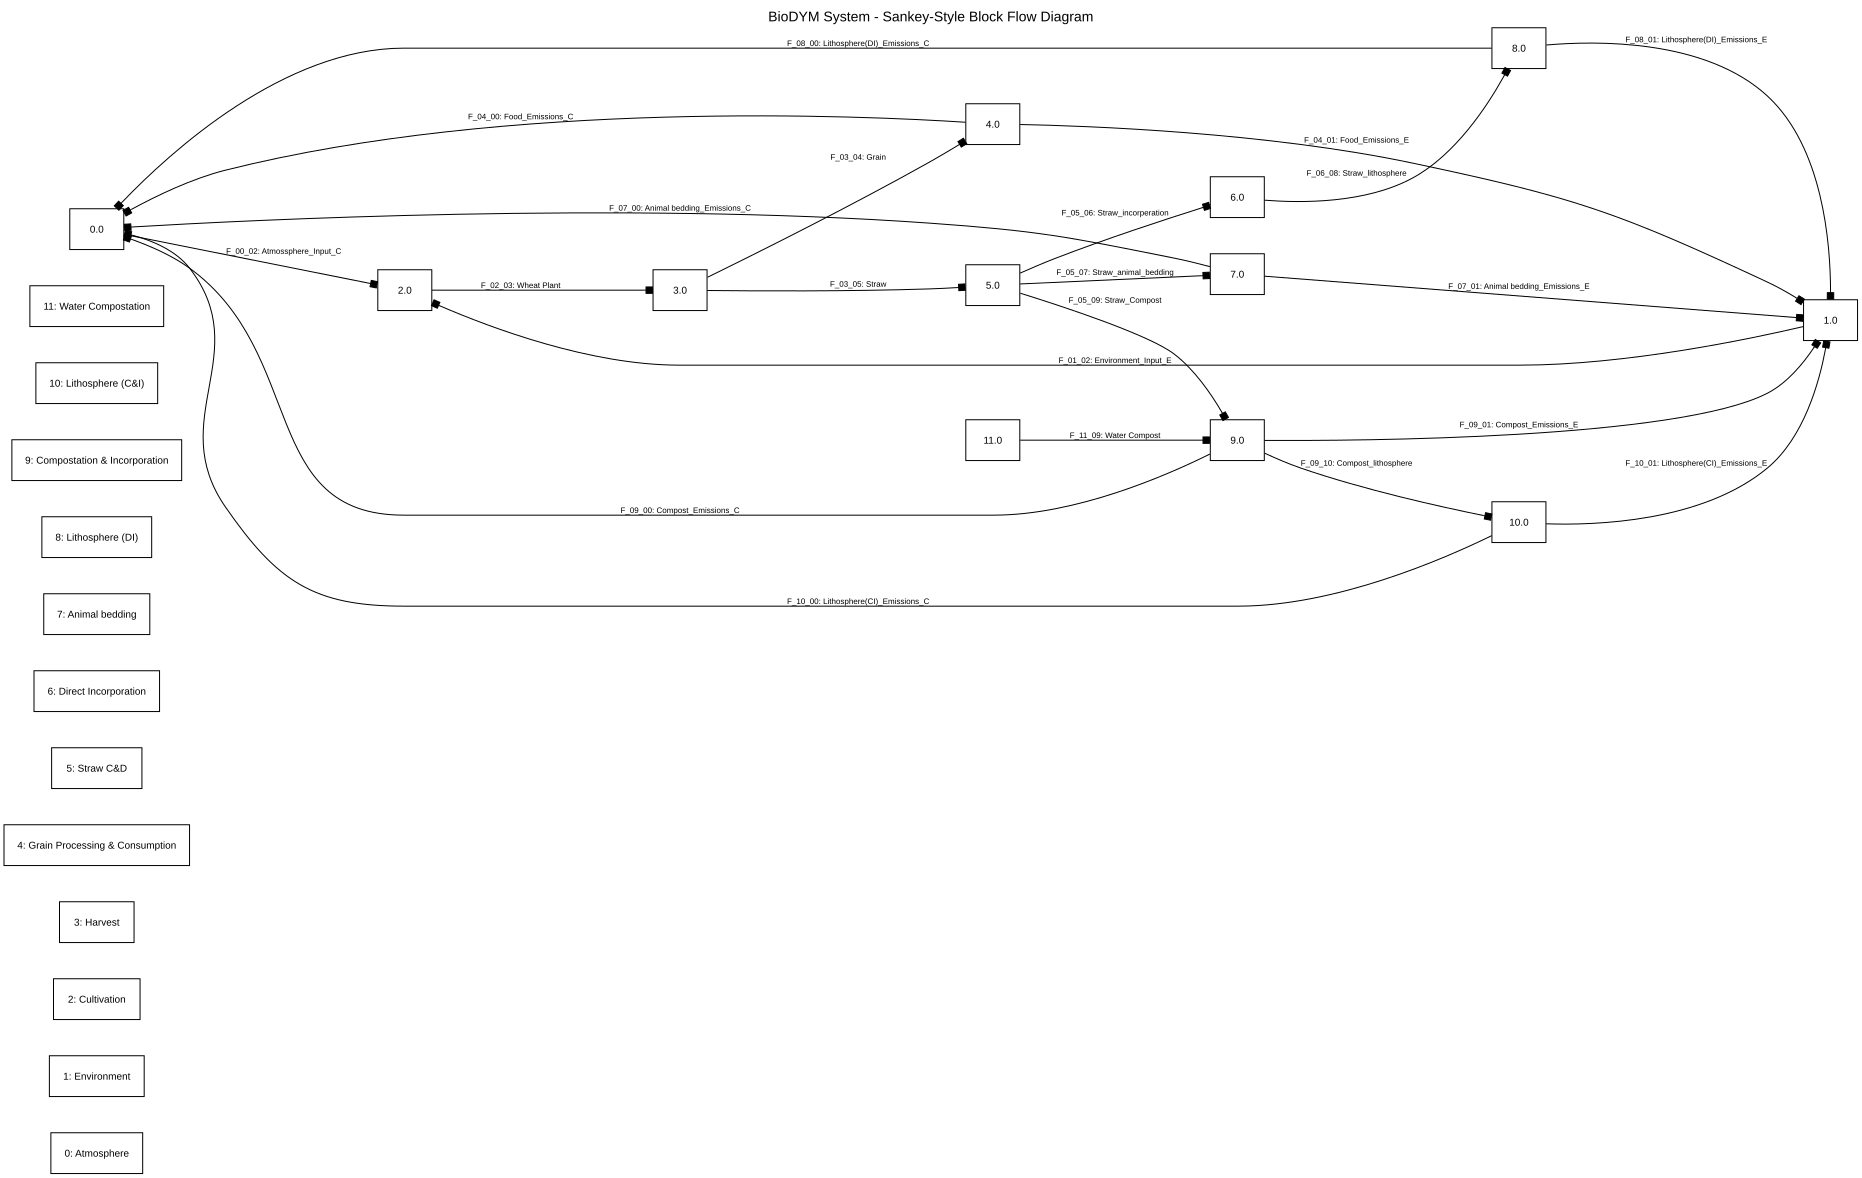

✅ Graphviz chart created successfully!


In [ ]:
# ## 2.3 System Flow Diagram (Graphviz)
print("\n--- System Flow Diagram (Graphviz) ---")
try:
    from plotting.graphviz_flow_charts import plot_graphviz_flow_chart_sankey_style
    
    # Get the required dataframes from the loaded data
    processes_data = all_excel_data['2_1_Definition_Processes']
    flows_data = all_excel_data['1_1_Definition_Flows']
    
    # Generate and display the chart
    dot_chart = plot_graphviz_flow_chart_sankey_style(processes_data, flows_data)
    if dot_chart:
        display(dot_chart)
        print("✅ Graphviz chart created successfully!")
except ImportError:
    print("⚠️ Graphviz library not found. Skipping this plot.")
except Exception as e:
    print(f"⚠️ Graphviz chart failed: {e}")

# 3. Visualization

In [ ]:
print("\n" + "="*60)
print("📊 VISUALIZATION (BASELINE)")
print("="*60)


📊 VISUALIZATION (BASELINE)


In [ ]:
# ## 3.1 Traditional Sankey Diagram
print("\n--- Traditional Sankey Diagram ---")
plotting.plot_interactive_sankey(mfa_results_baseline, dsm_params, fomp_params)


--- Traditional Sankey Diagram ---


FigureWidget({
    'data': [{'arrangement': 'snap',
              'link': {'color': [#1f77b4, #1f77b4, #1f77b4, #1f77b4, #1f77b4,
                                 #1f77b4, #1f77b4, #1f77b4, #1f77b4, #1f77b4,
                                 #1f77b4, #1f77b4, #1f77b4, #1f77b4, #1f77b4,
                                 #1f77b4, #1f77b4, #1f77b4, #1f77b4, #1f77b4,
                                 #1f77b4],
                       'customdata': [F_00_02, F_01_02, F_02_03, F_03_04, F_03_05,
                                      F_04_00, F_04_01, F_05_06, F_06_08, F_05_07,
                                      F_07_00, F_07_01, F_08_00, F_08_01, F_05_09,
                                      F_09_00, F_09_01, F_10_00, F_10_01, F_09_10,
                                      F_11_09],
                       'hovertemplate': ('Flow: %{customdata}<br />Sourc' ... 'Value: %{value}<extra></extra>'),
                       'source': [0, 1, 2, 3, 3, 4, 4, 5, 6, 5, 7, 7, 8, 8, 5, 9,
                  

In [ ]:
# ## 3.2 Enhanced Sankey Diagram
print("\n--- Enhanced Sankey Diagram ---")
try:
    from plotting.enhanced_sankey import plot_enhanced_sankey
    print("🎯 Creating enhanced Sankey diagram...")
    plot_enhanced_sankey(
        mfa_system_results=mfa_results_baseline,
        dsm_params=dsm_params,
        fomp_params=fomp_params,
        visualization_config_path=input_file
    )
    print("✅ Enhanced Sankey diagram created successfully!")
except Exception as e:
    print(f"⚠️ Enhanced Sankey diagram failed: {e}")
    import traceback
    traceback.print_exc()


--- Enhanced Sankey Diagram ---
🎯 Creating enhanced Sankey diagram...
Loading visualization configuration from Excel...
  Loaded and processed 6_1_Visualization_Processes


c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed



  Loaded 6_2_Visualization_Flows
  Loaded 6_3_Layout_Configuration
Visualization configuration loaded successfully


✅ Enhanced Sankey diagram created successfully!


In [ ]:
# ## 3.3 Additional Visualizations
print("\n--- Additional Visualizations ---")
plotting.plot_process_dynamics(mfa_results_baseline, all_excel_data['2_1_Definition_Processes'])
plotting.plot_flow_dynamics(mfa_results_baseline)
plotting.plot_stock_bar_chart(mfa_results_baseline, title="Stock Levels Over Time (Baseline)")
if dsm_params and dsm_details_baseline:
    plotting.plot_dsm_stock_details(mfa_results_baseline, dsm_params, dsm_details_baseline)
if fomp_params:
    plotting.plot_fomp_stock_details(mfa_results_baseline, fomp_params)


--- Additional Visualizations ---


interactive(children=(Dropdown(description='Process:', options=('Atmosphere', 'Environment', 'Cultivation', 'H…

FigureWidget({
    'data': [{'mode': 'lines',
              'name': 'Inflow',
              'type': 'scatter',
              'uid': 'cc6ece03-bf7a-46e0-8bec-4e05f03a4577',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050],
              'xaxis': 'x',
              'y': array([196711.3533339 , 253141.65477297, 221023.37305429, 231368.97962912,
                          288694.33947293, 280482.29253234, 323711.27760064, 318079.44212416,
                          345617.40834031, 319743.25441153, 306670.19474858, 303254.24417068,
                          341531.92830642, 337280.02016637, 308176.22198213, 356699.49734482,
                          315498.79638598, 333440.83250762, 327497.42374926, 303020.70958523,
                          305669.08862272, 325084.91655997, 331978.15516   , 292006.16980175,
                   

interactive(children=(SelectMultiple(description='Flows:', index=(0,), options=('F_00_02', 'F_01_02', 'F_02_03…

FigureWidget({
    'data': [{'mode': 'lines',
              'name': 'F_00_02',
              'type': 'scatter',
              'uid': 'e2d635b3-cc5e-4b5b-bcdb-d1d760deebf9',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050],
              'y': array([297904.57, 339142.51, 257050.15, 264047.97, 344153.42, 315342.38,
                          374614.06, 353051.01, 389483.15, 341176.45, 322450.14, 320237.29,
                          379904.01, 365226.01, 317828.87, 395868.9 , 324278.5 , 356002.85,
                          344691.02, 307492.17, 316566.75, 347388.93, 353799.33, 289510.81,
                          341760.05, 335915.31])}],
    'layout': {'barmode': 'overlay',
               'hovermode': 'x unified',
               'template': '...',
               'title': {'text': 'Time Series for Selected Flows (MATERIAL)'},

interactive(children=(IntSlider(value=2025, description='Year', max=2050, min=2025), Dropdown(description='Ele…

FigureWidget({
    'data': [{'hovertemplate': '<b>%{x}</b><br>Stock: %{y:.2f} Mg<extra></extra>',
              'marker': {'color': ['#2ca02c', '#2ca02c', '#2ca02c', '#2ca02c', '#2ca02c']},
              'type': 'bar',
              'uid': '57cb2e5d-2ee8-4584-9a26-9f0537eeb014',
              'x': array(['Atmosphere', 'Environment', 'Lithosphere (DI)', 'Lithosphere (C&I)',
                          'Water Compostation'], dtype=object),
              'y': array([0., 0., 0., 0., 0.])}],
    'layout': {'font': {'family': 'Arial, sans-serif', 'size': 12},
               'showlegend': False,
               'template': '...',
               'title': {'font': {'family': 'Arial, sans-serif', 'size': 20},
                         'text': 'Stock Levels Over Time (Baseline) - MATERIAL (2025)',
                         'x': 0.5},
               'xaxis': {'linecolor': 'black',
                         'linewidth': 1,
                         'showgrid': False,
                         'tickangle': 

FigureWidget({
    'data': [{'hovertemplate': '<b>Stock</b><br>Year: %{x}<br>Mass: %{y:.2f} Mg<extra></extra>',
              'line': {'color': '#2ca02c', 'width': 3},
              'marker': {'size': 4},
              'mode': 'lines+markers',
              'name': 'Organic Matter Stock',
              'type': 'scatter',
              'uid': 'c4d9a936-434e-43c2-a7ef-842bbf0038fd',
              'x': [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034,
                    2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044,
                    2045, 2046, 2047, 2048, 2049, 2050],
              'y': array([      0.        ,  208930.40582272,  387689.40160252,  464281.8583278 ,
                           534383.83455606,  651902.26545758,  727544.30274171,  836720.25947223,
                           913605.98066366, 1009270.78518178, 1059142.58745895, 1097601.86434228,
                          1138740.55455916, 1224252.80477824, 1288706.10188994, 1315735.64432145,
       

# 4. Scenario & Uncertainty Manager

In [ ]:
# ## 4.1 Scenario Analysis & Comparison
if getattr(config_obj, 'Run_Scenario_Analysis', False):
    # Find all scenarios defined in the config object
    scenario_names_to_run = []
    for i in range(1, 10): # Check for up to 9 scenarios
        attr_name = f'Selected_Scenario_Name_{i}'
        if hasattr(config_obj, attr_name):
            scenario_name = getattr(config_obj, attr_name)
            if scenario_name and not pd.isna(scenario_name):
                scenario_names_to_run.append(scenario_name)

    if not scenario_names_to_run:
        print("⚠️ Scenario Analysis is enabled, but no scenarios are selected in the configuration.")
    else:
        print(f"Found {len(scenario_names_to_run)} scenarios to run: {scenario_names_to_run}")
        all_scenario_results = {}
        scenario_definitions = data_loader.load_scenario_definitions(all_excel_data)

        for scenario_name in scenario_names_to_run:
            print("\n" + "="*60)
            print(f"🎭 RUNNING SCENARIO: '{scenario_name}'")
            print("="*60)

            if scenario_name not in scenario_definitions:
                print(f"⚠️ WARNING: Scenario '{scenario_name}' not found in '5_1_Scenario_Manager' sheet! Skipping.")
                continue

            mfa_system_scenario = copy.deepcopy(mfa_system_configured)
            mfa_system_scenario = system_setup.apply_scenario(mfa_system_scenario, scenario_definitions, scenario_name)

            scenario_config_obj = copy.deepcopy(config_obj)
            scenario_config_obj.RUN_MONTE_CARLO = False
            
            mfa_results_scenario, _ = solver.run_mfa_calculation(mfa_system_scenario, dsm_params, fomp_params, scenario_config_obj)
            all_scenario_results[scenario_name] = mfa_results_scenario
            print(f"✅ Scenario '{scenario_name}' calculation completed successfully!")

        if all_scenario_results:
            import importlib
            importlib.reload(plotting)
            print("\n" + "="*60)
            print("📊 MULTI-SCENARIO VS. BASELINE COMPARISON")
            print("="*60)
            plotting.plot_multi_scenario_comparison(
                baseline_results=mfa_results_baseline, 
                all_scenario_results=all_scenario_results,
                scenario_definitions=scenario_definitions
            )
            
            print("\n--- Enhanced Sankey Comparison ---")
            try:
                from plotting.enhanced_sankey import plot_enhanced_sankey
                print("🎯 Creating enhanced Sankey diagrams for scenario comparison...")
                
                print("\n📊 Baseline - Enhanced Sankey:")
                plot_enhanced_sankey(
                    mfa_system_results=mfa_results_baseline,
                    dsm_params=dsm_params,
                    fomp_params=fomp_params,
                    visualization_config_path=input_file
                )
                
                if scenario_names_to_run:
                    first_scenario = scenario_names_to_run[0]
                    if first_scenario in all_scenario_results:
                        print(f"\n📊 Scenario '{first_scenario}' - Enhanced Sankey:")
                        plot_enhanced_sankey(
                            mfa_system_results=all_scenario_results[first_scenario],
                            dsm_params=dsm_params,
                            fomp_params=fomp_params,
                            visualization_config_path=input_file
                        )
                
                print("✅ Enhanced Sankey comparison completed!")
            except Exception as e:
                print(f"⚠️ Enhanced Sankey comparison failed: {e}")
                import traceback
                traceback.print_exc()

In [ ]:
# ## 4.2 Monte Carlo Analysis
print("\n" + "="*60)
print("🎲 MONTE CARLO SIMULATION (BASELINE)")
print("="*60)


🎲 MONTE CARLO SIMULATION (BASELINE)


In [ ]:
if config_obj.RUN_MONTE_CARLO and '4_1_Uncertainty_Parameters' in input_data:
    try:
        from engine.mc_simulation import run_mc_simulation
        from plotting.mc_visuals import plot_interactive_mc_histogram, plot_interactive_tornado
        mc_results = run_mc_simulation(mfa_system_configured, input_data, dsm_params, fomp_params, config_obj)
        if mc_results is not None and not mc_results.empty:
            print("✅ Monte Carlo simulation completed for baseline")
            plot_interactive_mc_histogram(mc_results)
            plot_interactive_tornado(mc_results)
    except Exception as e:
        print(f"⚠️ Monte Carlo simulation failed: {e}")
        import traceback
        traceback.print_exc()
else:
    print("ℹ️ Monte Carlo analysis is disabled or no uncertainty parameters are defined. Skipping.")


[MC] Parameter Validation Warnings:
  ⚠️ WARNING: Process 5 has 3 outputs but only 0 TCs in MC. Missing: ['F_05_06', 'F_05_07', 'F_05_09']
  ⚠️ WARNING: Process 5 has 3 outputs but only 0 TCs in MC. Missing: ['F_05_06', 'F_05_07', 'F_05_09']
  ⚠️ WARNING: Process 5 has 3 outputs but only 0 TCs in MC. Missing: ['F_05_06', 'F_05_07', 'F_05_09']
  ⚠️ WARNING: Process 3 has 2 outputs but only 0 TCs in MC. Missing: ['F_03_04', 'F_03_05']
  ⚠️ WARNING: Process 3 has 2 outputs but only 0 TCs in MC. Missing: ['F_03_04', 'F_03_05']


[MC] Running Monte Carlo simulation with 25 iterations...
[MC] Using 5 validated parameters...
  Running iteration 1/25...
   Total carbon output: 2072601.70
   Total environmental output: 2245318.50
   Total carbon output: 94952.56
   Total environmental output: 87648.52
   Total carbon output: 2072601.70
   Total environmental output: 2245318.50
   Total carbon output: 94952.56
   Total environmental output: 87648.52
   Total carbon output: 2072601.70
   Total e

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

c:\Users\Johannes\anaconda3\envs\biODYM_anaconda_environment\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning:

invalid value encountered in divide



# 5. Data Export

In [ ]:
print("\n" + "="*60)
print("💾 EXPORTING BASELINE RESULTS")
print("="*60)


💾 EXPORTING BASELINE RESULTS


In [ ]:
output_file = "data/02_output/results_scientific_baseline.xlsx"
utils.export_results_to_excel(mfa_results_baseline, output_file, input_file_path=input_file)
print(f"✅ Baseline results exported to: {output_file}")

--> Exporting results to 'data/02_output/results_scientific_baseline.xlsx'...
✅ Results successfully exported to data/02_output/results_scientific_baseline.xlsx
✅ Baseline results exported to: data/02_output/results_scientific_baseline.xlsx


In [ ]:
print("\n" + "="*60)
print("🎉 ANALYSIS COMPLETE")
print("="*60)


🎉 ANALYSIS COMPLETE
